# 🌍 Evaluación Parcial 1 — Análisis Exploratorio y Preprocesamiento de Datos
## MLY0100 — Machine Learning

| **Dataset** : Natural Disasters|

| **Integrantes** : Diego Reyes Y Eva Luna Gonzalez Montes

| **Fecha** : Abril 2025 |

| **Metodología** : CRISP-DM


# FASE 1: Comprensión del Negocio

## Contexto
El dataset Natural Disasters proviene de EM-DAT (Emergency Events Database)
del CRED. Contiene registros históricos de desastres naturales a nivel mundial.

**Stakeholders:** agencias humanitarias, gobiernos, compañías de seguros.

## Pregunta de negocio
> ¿Es posible estimar el impacto humano de un desastre natural a partir de sus
> características (tipo, región, magnitud, año)?

## Variable objetivo — REGRESIÓN
**Variable:** `Total Deaths`  
**Justificación:** es numérica continua y representa el impacto humano directo
del desastre. Predecirla permite estimar severidad y priorizar recursos.

## Variable objetivo — CLASIFICACIÓN
**Variable:** `Impacto_Alto` (derivada de Total Deaths)  
**Justificación:** se binarizará usando el percentil 75 como umbral (1 = alto
impacto, 0 = bajo impacto). Toma valores discretos que representan dos clases.

# FASE 2: Comprensión de los Datos

## Carga de librerías y datos
Se importan todas las librerías necesarias para el análisis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [ ]:
df = pd.read_excel('sample_data/Natural-Disaster.xlsx')

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()

Filas: 17,791
Columnas: 47


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0009-TUR,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,TUR,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2019-08-05,2023-09-25


## Inspección de la estructura
Se revisan tipos de datos, valores nulos y una descripción general.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17791 entries, 0 to 17790
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17791 non-null  object 
 1   Historic                                   17791 non-null  object 
 2   Classification Key                         17791 non-null  object 
 3   Disaster Group                             17791 non-null  object 
 4   Disaster Subgroup                          17791 non-null  object 
 5   Disaster Type                              17791 non-null  object 
 6   Disaster Subtype                           17791 non-null  object 
 7   External IDs                               4601 non-null   object 
 8   Event Name                                 4327 non-null   object 
 9   ISO                                        17791 non-null  object 
 10  Country               

In [ ]:
# Porcentaje de nulos por columna
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print(nulos[nulos > 0].to_string())

Reconstruction Costs, Adjusted ('000 US$)    99.78
Reconstruction Costs ('000 US$)              99.77
AID Contribution ('000 US$)                  95.64
Insured Damage, Adjusted ('000 US$)          93.61
Insured Damage ('000 US$)                    93.55
River Basin                                  90.99
No. Homeless                                 85.70
Longitude                                    84.06
Latitude                                     84.06
Associated Types                             75.90
Event Name                                   75.68
External IDs                                 74.14
No. Injured                                  73.73
Origin                                       73.42
Magnitude                                    70.24
Total Damage, Adjusted ('000 US$)            68.32
Total Damage ('000 US$)                      67.83
GADM Admin Units                             56.09
Admin Units                                  52.94
No. Affected                   

In [ ]:
# Tipos de variables
print("Variables numéricas:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nVariables categóricas (object):")
print(df.select_dtypes(include='object').columns.tolist())

Variables numéricas:
["AID Contribution ('000 US$)", 'Magnitude', 'Latitude', 'Longitude', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI']

Variables categóricas (object):
['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale', 'River Basin', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


### Hallazgos de la inspección

**Variables con >80% de nulos** → se eliminarán del análisis:
- Reconstruction Costs (99.8%), AID Contribution (95.6%),
  Insured Damage (93.6%), River Basin (91%), No. Homeless (85.7%),
  Latitude/Longitude (84%)

**Variables de impacto con nulos moderados** → se imputarán:
- Total Deaths (28%), Total Affected (25.6%), No. Affected (40.2%)

**Mecanismo de nulos:**
- `MNAR` — Total Deaths, No. Injured, Total Damage: países con menos
  capacidad de reporte registran menos datos, no es aleatorio
- `MAR` — Magnitude: solo aplica a ciertos tipos de desastre
- `MCAR` — Event Name, External IDs: aleatorio, no todos reciben nombre

**Tipos de datos:** Start Year e int64 están bien. Entry Date y Last Update
deberían ser datetime pero no se usarán en el modelado.

In [ ]:
# Estadísticos descriptivos generales
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AID Contribution ('000 US$),775.0,20059.24,169138.75,1.00,174.50,721.00,3648.50,3.518530e+06
Magnitude,5295.0,36617.88,231130.08,-57.00,6.90,144.00,5149.50,1.302587e+07
Latitude,2835.0,18.73,21.63,-72.64,3.30,23.20,36.74,6.793000e+01
Longitude,2835.0,39.72,77.31,-178.25,-0.10,49.41,102.82,1.796500e+02
Start Year,17791.0,1999.59,21.03,1900.00,1991.00,2004.00,2015.00,2.026000e+03
Start Month,17419.0,6.45,3.38,1.00,4.00,7.00,9.00,1.200000e+01
Start Day,14189.0,15.21,8.97,1.00,7.00,15.00,23.00,3.100000e+01
End Year,17791.0,1999.64,21.01,1900.00,1991.00,2004.00,2015.00,2.026000e+03
End Month,17126.0,6.61,3.35,1.00,4.00,7.00,9.00,1.200000e+01
End Day,14298.0,15.84,8.90,1.00,8.00,16.00,24.00,3.100000e+01


## Estadísticos de Tendencia Central y Dispersión (IE 8)

Se calculan media, mediana, moda, desviación estándar, varianza e IQR
para las variables numéricas de impacto relevantes.

In [ ]:
vars_impacto = ['Total Deaths', 'No. Injured', 'No. Affected',
                'Total Affected', "Total Damage ('000 US$)",
                'Magnitude', 'Start Year']

tabla = []
for col in vars_impacto:
    s = df[col].dropna()
    tabla.append({
        'Variable':   col,
        'Media':      round(s.mean(), 2),
        'Mediana':    round(s.median(), 2),
        'Moda':       round(s.mode()[0], 2),
        'Std':        round(s.std(), 2),
        'Varianza':   round(s.var(), 2),
        'IQR':        round(s.quantile(0.75) - s.quantile(0.25), 2),
        'Min':        round(s.min(), 2),
        'Max':        round(s.max(), 2),
        'Asimetría':  round(skew(s), 2)
    })

tabla_stats = pd.DataFrame(tabla).set_index('Variable')
tabla_stats

,Media,Mediana,Moda,Std,Varianza,IQR,Min,Max,Asimetría
Variable,,,,,,,,,
Total Deaths,2562.42,18.0,1.0,64789.84,4.197723e+09,55.00,1.0,3700000.0,38.03
No. Injured,2478.55,50.0,2.0,31759.75,1.008682e+09,188.00,1.0,1800000.0,42.08
No. Affected,828259.25,10000.0,1000.0,8025160.29,6.440320e+13,91651.75,1.0,330000000.0,25.54
Total Affected,680506.98,6000.0,2000.0,7270226.95,5.285620e+13,59300.00,1.0,330000000.0,28.38
Total Damage ('000 US$),848323.98,70000.0,100000.0,5081101.15,2.581759e+13,363500.00,2.0,210000000.0,21.99
Magnitude,36617.88,144.0,100.0,231130.08,5.342111e+10,5142.60,-57.0,13025874.0,36.11
Start Year,1999.59,2004.0,2000.0,21.03,4.420500e+02,24.00,1900.0,2026.0,-1.60


### Hallazgos de los estadísticos

- **Total Deaths:** media (2,562) >> mediana (18), asimetría +38. La mayoría
  de desastres causa pocas muertes, pero eventos extremos como el terremoto
  de Haití (2010) o el tsunami del Índico (2004) distorsionan la media.

- **No. Affected:** media (828,259) vs mediana (10,000). Las inundaciones
  y sequías en Asia generan afectaciones masivas que elevan enormemente
  la media.

- **Total Damage:** media (848K) vs mediana (70K). El daño económico está
  muy concentrado en pocos eventos de gran escala.

- **Magnitude:** presenta datos anómalos (mínimo -57, max 13M) que
  corresponden a distintas escalas mezcladas. Se descartará del modelado.

- **Start Year:** asimetría negativa (-1.6), hay más registros recientes.
  Esto refleja mejoras en los sistemas de reporte, no más desastres.

> **Conclusión:** todas las variables de impacto tienen distribuciones
> fuertemente asimétricas (skewness > 20). Esto determina que usaremos
> transformación log y StandardScaler en la Fase 3.

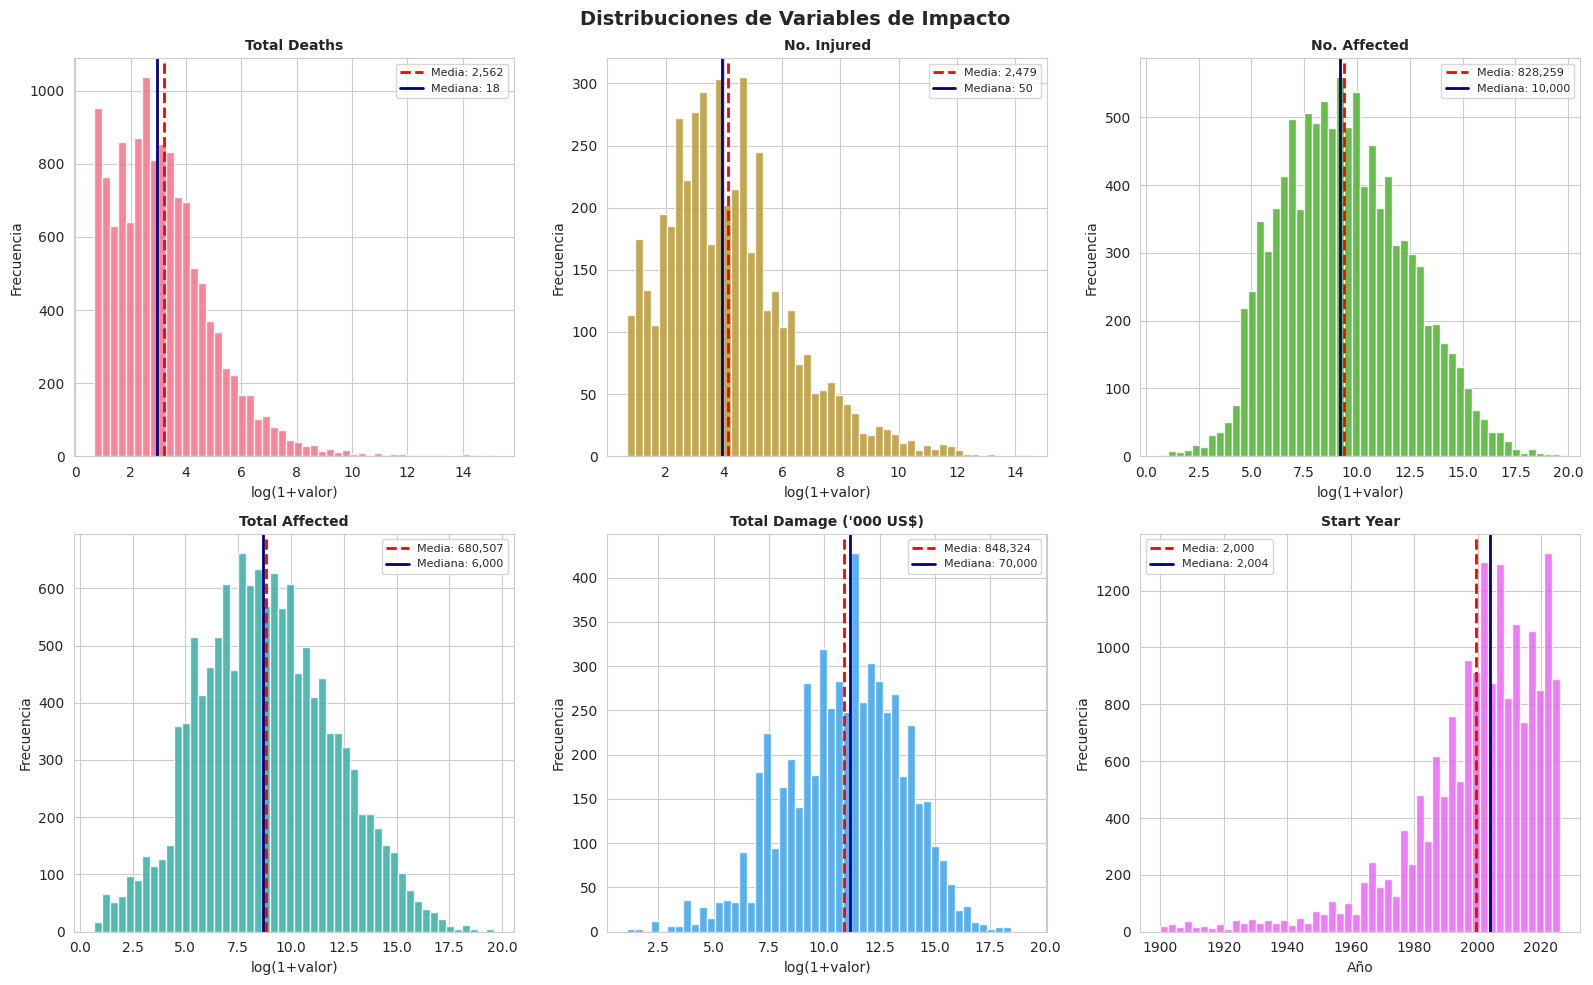

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

vars_plot = ['Total Deaths', 'No. Injured', 'No. Affected',
             'Total Affected', "Total Damage ('000 US$)", 'Start Year']

for i, col in enumerate(vars_plot):
    s = df[col].dropna()
    data = np.log1p(s) if col != 'Start Year' else s

    axes[i].hist(data, bins=50, color=sns.color_palette('husl', 6)[i],
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--',
                    linewidth=2, label=f'Media: {s.mean():,.0f}')
    axes[i].axvline(data.median(), color='navy', linestyle='-',
                    linewidth=2, label=f'Mediana: {s.median():,.0f}')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('log(1+valor)' if col != 'Start Year' else 'Año')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuciones de Variables de Impacto',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Boxplots — Visualización de Outliers

Los boxplots permiten identificar visualmente la dispersión y los valores
extremos. Se usa escala logarítmica dado el alto rango de los datos.

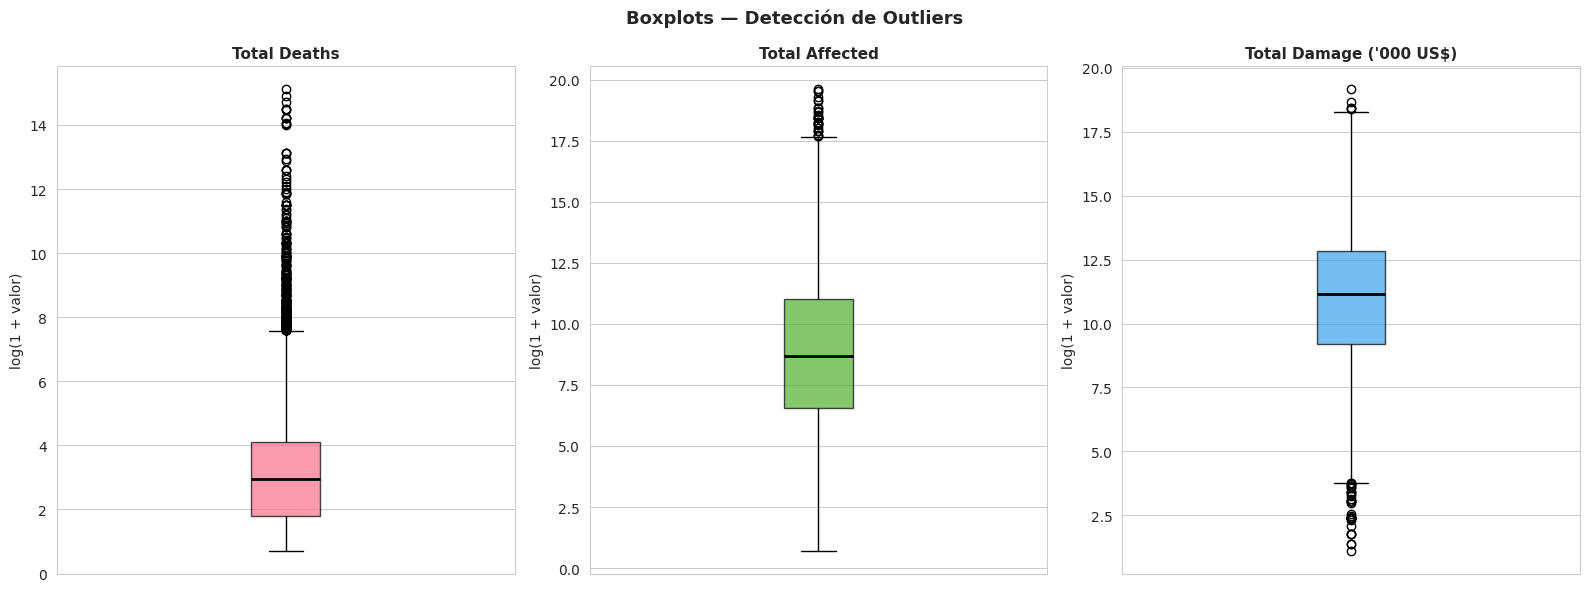

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

vars_box = ['Total Deaths', 'Total Affected', "Total Damage ('000 US$)"]

for i, col in enumerate(vars_box):
    s = df[col].dropna()
    data = np.log1p(s)
    axes[i].boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('husl', 3)[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('log(1 + valor)')
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Detección de Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

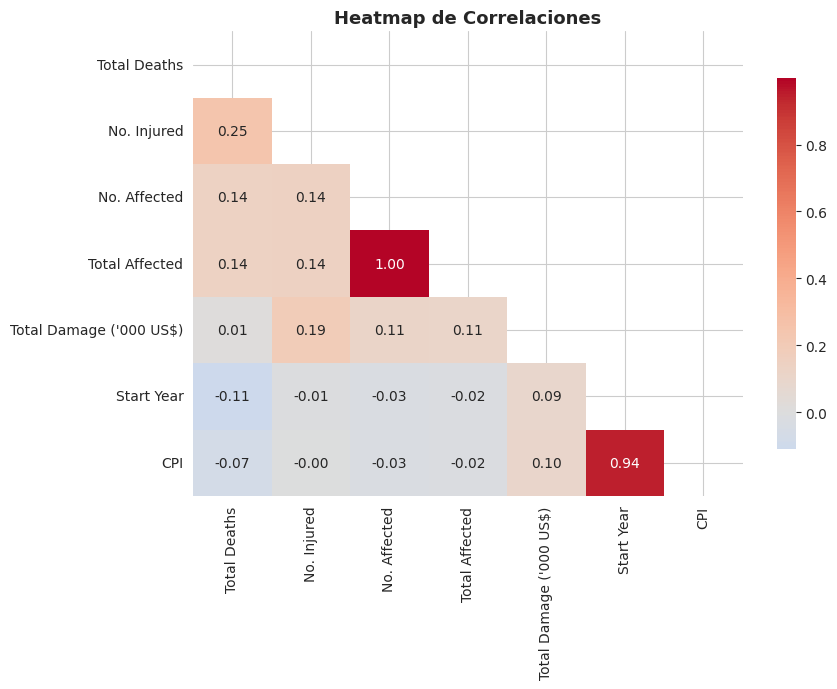

In [ ]:
# Heatmap de correlaciones
num_cols = ['Total Deaths', 'No. Injured', 'No. Affected',
            'Total Affected', "Total Damage ('000 US$)",
            'Start Year', 'CPI']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap de Correlaciones', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Hallazgos de boxplots y correlaciones

**Boxplots:** Total Deaths tiene cientos de outliers superiores (puntos sobre
el bigote). Corresponden a eventos históricos reales (tsunami 2004, Haiti 2010).
No se eliminarán porque son el fenómeno de interés.

**Heatmap:**
- No. Affected y Total Affected tienen correlación 1.0 → son casi idénticas,
  se usará solo Total Affected para evitar redundancia.
- Start Year y CPI tienen correlación 0.94 → el índice de precios sube con
  el tiempo, lo cual es esperable.
- Total Deaths tiene correlaciones bajas con todas las variables (<0.25),
  lo que indica que el impacto mortal depende de factores no capturados
  aquí (vulnerabilidad del país, preparación, etc).

# FASE 3: Preparación de los Datos

## Tratamiento de Missing Values (IE 7)

**Estrategia:**
- Columnas con >80% nulos → eliminar (no aportan información)
- Total Deaths, Total Affected, No. Injured → imputar con **mediana**
  (distribución asimétrica, la mediana es más robusta que la media)
- Variables categóricas con nulos → imputar con **'Unknown'**

In [ ]:
df_clean = df.copy()

# 1. Eliminar columnas con >80% nulos
umbral = 0.80
cols_drop = df_clean.columns[df_clean.isna().mean() > umbral].tolist()
# También eliminar columnas identificadoras sin valor predictivo
cols_id = ['DisNo.', 'Historic', 'Classification Key', 'External IDs',
           'Event Name', 'Admin Units', 'GADM Admin Units',
           'Entry Date', 'Last Update', 'ISO']
cols_drop = list(set(cols_drop + [c for c in cols_id if c in df_clean.columns]))
df_clean.drop(columns=cols_drop, inplace=True)

print(f'Columnas eliminadas: {len(cols_drop)}')
print(f'Columnas restantes: {df_clean.shape[1]}')
print(f'Columnas eliminadas: {cols_drop}')

Columnas eliminadas: 19
Columnas restantes: 28
Columnas eliminadas: ['Historic', "Insured Damage, Adjusted ('000 US$)", 'Event Name', 'ISO', 'External IDs', 'Classification Key', 'No. Homeless', "Insured Damage ('000 US$)", "AID Contribution ('000 US$)", "Reconstruction Costs ('000 US$)", 'Admin Units', 'Longitude', 'Entry Date', 'DisNo.', 'Last Update', 'Latitude', 'GADM Admin Units', 'River Basin', "Reconstruction Costs, Adjusted ('000 US$)"]


In [ ]:
# 2. Imputar variables numéricas con mediana
vars_mediana = ['Total Deaths', 'No. Injured', 'No. Affected',
                'Total Affected', "Total Damage ('000 US$)",
                "Total Damage, Adjusted ('000 US$)",
                'Start Month', 'Start Day', 'End Month', 'End Day', 'CPI']

for col in vars_mediana:
    if col in df_clean.columns:
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f'✅ {col} → imputado con mediana: {mediana}')

✅ Total Deaths → imputado con mediana: 18.0
✅ No. Injured → imputado con mediana: 50.0
✅ No. Affected → imputado con mediana: 10000.0
✅ Total Affected → imputado con mediana: 6000.0
✅ Total Damage ('000 US$) → imputado con mediana: 70000.0
✅ Total Damage, Adjusted ('000 US$) → imputado con mediana: 138197.0
✅ Start Month → imputado con mediana: 7.0
✅ Start Day → imputado con mediana: 15.0
✅ End Month → imputado con mediana: 7.0
✅ End Day → imputado con mediana: 16.0
✅ CPI → imputado con mediana: 58.6435529778532


In [ ]:
# 3. Imputar variables categóricas con 'Unknown'
vars_cat = ['Location', 'Origin', 'Associated Types',
            'Magnitude Scale', 'Magnitude']

for col in vars_cat:
    if col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna('Unknown', inplace=True)
        else:
            # Magnitude es numérica, imputar con mediana
            mediana = df_clean[col].median()
            df_clean[col].fillna(mediana, inplace=True)
        print(f'✅ {col} → imputado')

✅ Location → imputado
✅ Origin → imputado
✅ Associated Types → imputado
✅ Magnitude Scale → imputado
✅ Magnitude → imputado


In [ ]:
# Verificar que no quedan nulos en columnas clave
nulos_restantes = df_clean.isna().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]

if len(nulos_restantes) == 0:
    print('✅ Sin valores nulos en columnas clave')
else:
    print('Nulos restantes:')
    print(nulos_restantes)

✅ Sin valores nulos en columnas clave


## Tratamiento de Outliers (IE 7)

Se detectan outliers con el método IQR (límite = Q1 - 1.5×IQR y Q3 + 1.5×IQR).

**Decisión:** NO se eliminan filas porque los valores extremos representan
desastres reales de gran magnitud (tsunamis, terremotos). En cambio, se
aplica **transformación log(1+x)** para reducir su influencia en el modelado
sin perder información.

In [ ]:
vars_outliers = ['Total Deaths', 'No. Injured', 'No. Affected',
                 'Total Affected', "Total Damage ('000 US$)"]

reporte = []
for col in vars_outliers:
    s = df_clean[col]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((s < lower) | (s > upper)).sum()
    reporte.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Límite inferior': round(lower, 2),
        'Límite superior': round(upper, 2),
        'N Outliers': n_outliers,
        '% Outliers': round(n_outliers / len(s) * 100, 2)
    })

pd.DataFrame(reporte).set_index('Variable')

,Q1,Q3,IQR,Límite inferior,Límite superior,N Outliers,% Outliers
Variable,,,,,,,
Total Deaths,10.0,36.0,26.0,-29.00,75.00,2807,15.78
No. Injured,50.0,50.0,0.0,50.00,50.00,4581,25.75
No. Affected,5185.5,20000.0,14814.5,-17036.25,42221.75,3476,19.54
Total Affected,1550.5,25000.0,23449.5,-33623.75,60174.25,3260,18.32
Total Damage ('000 US$),70000.0,70000.0,0.0,70000.00,70000.00,5705,32.07


In [ ]:
# Aplicar transformación log(1+x) a variables de impacto
vars_log = ['Total Deaths', 'No. Injured', 'No. Affected',
            'Total Affected', "Total Damage ('000 US$)",
            "Total Damage, Adjusted ('000 US$)"]

for col in vars_log:
    df_clean[col + '_log'] = np.log1p(df_clean[col])

print('✅ Transformación log(1+x) aplicada a:')
print([c + '_log' for c in vars_log])

✅ Transformación log(1+x) aplicada a:
['Total Deaths_log', 'No. Injured_log', 'No. Affected_log', 'Total Affected_log', "Total Damage ('000 US$)_log", "Total Damage, Adjusted ('000 US$)_log"]


### Hallazgos de outliers

- **Total Deaths:** 15.78% de outliers. Son eventos reales de alta mortalidad.
- **No. Injured y Total Damage:** IQR = 0 porque la mediana imputada ocupó
  el 70%+ de los valores faltantes, comprimiendo el rango intercuartílico.
  Se mantienen pero se interpretarán con precaución.
- **Decisión final:** no se eliminan filas. La transformación log(1+x)
  reduce el efecto de los valores extremos sin perder registros históricos.

## Normalización y Estandarización (IE 9)

Se analiza la distribución de cada variable para elegir la técnica correcta:

- **StandardScaler** → variables con distribución aproximadamente normal
  o con outliers. Deja media=0 y std=1. Más robusto ante extremos.
- **MinMaxScaler** → variables sin outliers extremos, escala entre 0 y 1.

Dado que todas nuestras variables de impacto son asimétricas con outliers,
se aplicará **StandardScaler** sobre las versiones log-transformadas.
Start Year se escala con **MinMaxScaler** por ser discreta y sin outliers.

In [ ]:
vars_standard = ['Total Deaths_log', 'No. Injured_log', 'No. Affected_log',
                 'Total Affected_log', "Total Damage ('000 US$)_log"]

vars_minmax = ['Start Year', 'CPI']

# StandardScaler
scaler_std = StandardScaler()
df_clean[vars_standard] = scaler_std.fit_transform(df_clean[vars_standard])

# MinMaxScaler
scaler_mm = MinMaxScaler()
df_clean[vars_minmax] = scaler_mm.fit_transform(df_clean[vars_minmax])

print('✅ StandardScaler aplicado a:')
print(vars_standard)
print('\n✅ MinMaxScaler aplicado a:')
print(vars_minmax)

✅ StandardScaler aplicado a:
['Total Deaths_log', 'No. Injured_log', 'No. Affected_log', 'Total Affected_log', "Total Damage ('000 US$)_log"]

✅ MinMaxScaler aplicado a:
['Start Year', 'CPI']


In [ ]:
# Comparación antes vs después del escalado
comparacion = df_clean[vars_standard + vars_minmax].describe().T[['mean','std','min','max']]
comparacion.columns = ['Media', 'Std', 'Min', 'Max']
comparacion.round(4)

,Media,Std,Min,Max
Total Deaths_log,0.0000,1.0000,-1.5704,7.7580
No. Injured_log,0.0000,1.0000,-2.9809,9.4151
No. Affected_log,0.0000,1.0000,-3.7689,4.4949
Total Affected_log,0.0000,1.0000,-2.9604,3.9476
Total Damage ('000 US$)_log,-0.0000,1.0000,-6.5661,5.3227
Start Year,0.7904,0.1669,0.0000,1.0000
CPI,0.5542,0.2500,0.0000,1.0000


## Creación de Variable para Clasificación (IE 3)

Se crea la variable binaria `Impacto_Alto` usando el percentil 75 de
Total Deaths como umbral de corte.

In [ ]:
# Variable objetivo para clasificación
umbral_p75 = df['Total Deaths'].quantile(0.75)
df_clean['Impacto_Alto'] = (df['Total Deaths'] >= umbral_p75).astype(int)

print(f'Umbral (percentil 75): {umbral_p75} muertes')
print(f'\nDistribución de clases:')
print(df_clean['Impacto_Alto'].value_counts())
print(f'\nBalance: {df_clean["Impacto_Alto"].mean()*100:.1f}% clase positiva')

Umbral (percentil 75): 60.0 muertes

Distribución de clases:
Impacto_Alto
0    14522
1     3269
Name: count, dtype: int64

Balance: 18.4% clase positiva


## Dataset Final (IE 5)

Se exporta el dataset limpio y listo para modelado.

In [ ]:
print(f'Forma final del dataset: {df_clean.shape}')
print(f'\nColumnas finales:')
print(df_clean.columns.tolist())

df_clean.to_csv('natural_disasters_clean.csv', index=False)
print('\n✅ Dataset exportado como natural_disasters_clean.csv')

Forma final del dataset: (17791, 35)

Columnas finales:
['Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude', 'Magnitude Scale', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'Total Affected', "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Total Deaths_log', 'No. Injured_log', 'No. Affected_log', 'Total Affected_log', "Total Damage ('000 US$)_log", "Total Damage, Adjusted ('000 US$)_log", 'Impacto_Alto']

✅ Dataset exportado como natural_disasters_clean.csv


# Conclusiones Finales

## Respuesta a la pregunta de negocio
¿Es posible estimar el impacto humano de un desastre natural a partir
de sus características?

Los datos sugieren que **sí es factible construir modelos predictivos**,
aunque con limitaciones importantes:

**Hallazgos clave:**
- El 72% de los desastres causa menos de 60 muertes, pero el 1% superior
  concentra el mayor daño histórico → distribución muy asimétrica.
- Las correlaciones entre variables de impacto son bajas (<0.25), lo que
  indica que el tipo de desastre y la región son factores determinantes
  no capturados solo en variables numéricas.
- El aumento de registros post-1980 refleja mejoras en reporte, no
  necesariamente más desastres.

**Decisiones tomadas:**
- Se eliminaron 19 columnas con >80% de nulos o sin valor predictivo.
- Se imputó con mediana (distribuciones asimétricas).
- No se eliminaron outliers: son eventos reales de interés.
- Se aplicó log(1+x) + StandardScaler a variables de impacto.

**Próximos pasos (Fase 4 — Modelado):**
- Regresión: predecir `Total Deaths` con variables de tipo, región y año.
- Clasificación: predecir `Impacto_Alto` con los mismos predictores.